# 02. Linear Baseline Models
This notebook implements simple linear models (OLS Linear Regression and Ridge Regression) to serve as initial machine learning benchmarks.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

ROOT = Path("../../")
DATA_PATH = ROOT / "data/processed/01_daily_merged.csv"

def split_df(df):
    TRAIN_FRAC = 0.70
    VAL_FRAC = 0.15
    dates = np.sort(df["date"].dt.normalize().unique())
    n = len(dates)
    tc = dates[int(n * TRAIN_FRAC)]
    vc = dates[int(n * (TRAIN_FRAC + VAL_FRAC))]
    df["split"] = "test"
    df.loc[df["date"] < tc, "split"] = "train"
    df.loc[(df["date"] >= tc) & (df["date"] < vc), "split"] = "val"
    return df

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = split_df(df)

MET_COLS = [
    "temperature_2m_C_mean", "relative_humidity_pct_mean",
    "wind_speed_10m_kmh_mean", "wind_u_10m_mean", "wind_v_10m_mean",
    "precipitation_mm_sum", "cloud_cover_pct_mean", "pressure_msl_hPa_mean"
]
LAG_COLS = [
    "pm25_lag1", "pm25_lag2", "pm25_lag3", "pm25_lag7",
    "pm25_roll3", "pm25_roll7", "pm25_roll7std"
]
FEATURE_COLS = MET_COLS + LAG_COLS

train_idx = df[df["split"] == "train"].index
val_idx = df[df["split"] == "val"].index
test_idx = df[df["split"] == "test"].index

imputer = SimpleImputer(strategy="median")
X_raw = df[FEATURE_COLS].values
X_imputed = X_raw.copy()
X_imputed[train_idx] = imputer.fit_transform(X_raw[train_idx])
if len(val_idx) > 0:
    X_imputed[val_idx] = imputer.transform(X_raw[val_idx])
if len(test_idx) > 0:
    X_imputed[test_idx] = imputer.transform(X_raw[test_idx])

scaler = StandardScaler()
X_scaled = X_raw.copy()
X_scaled[train_idx] = scaler.fit_transform(X_imputed[train_idx])
if len(val_idx) > 0:
    X_scaled[val_idx] = scaler.transform(X_imputed[val_idx])
if len(test_idx) > 0:
    X_scaled[test_idx] = scaler.transform(X_imputed[test_idx])

y = df["pm25"].values
indices = {"train": train_idx, "val": val_idx, "test": test_idx}

def evaluate_model(model, name, X_data, y_data, indices_dict):
    print(f"=== {name} ===")
    for split, idxs in indices_dict.items():
        if len(idxs) == 0: continue
        preds = model.predict(X_data[idxs])
        r2 = r2_score(y_data[idxs], preds)
        mae = mean_absolute_error(y_data[idxs], preds)
        rmse = np.sqrt(mean_squared_error(y_data[idxs], preds))
        print(f"{split.capitalize()} -> R2: {r2:.4f}, MAE: {mae:.3f}, RMSE: {rmse:.3f}")


## 1. Ordinary Least Squares (OLS) Linear Regression

In [2]:
lr = LinearRegression()
lr.fit(X_scaled[train_idx], y[train_idx])
evaluate_model(lr, "OLS Linear Regression", X_scaled, y, indices)


=== OLS Linear Regression ===
Train -> R2: 0.7348, MAE: 9.610, RMSE: 14.656
Val -> R2: 0.7531, MAE: 11.020, RMSE: 16.579
Test -> R2: 0.7116, MAE: 10.633, RMSE: 14.676


## 2. Ridge Regression (L2 Regularized)
We use L2 weight decay to prevent overfitting on temporal autocorrelation.

In [3]:
ridge = Ridge(alpha=10.0)
ridge.fit(X_scaled[train_idx], y[train_idx])
evaluate_model(ridge, "Ridge Regression (alpha=10.0)", X_scaled, y, indices)


=== Ridge Regression (alpha=10.0) ===
Train -> R2: 0.7347, MAE: 9.634, RMSE: 14.658
Val -> R2: 0.7504, MAE: 11.089, RMSE: 16.669
Test -> R2: 0.7109, MAE: 10.653, RMSE: 14.695


## 3. Coefficient Interpretation
Plot the coefficients values of the Ridge model to see feature impact.

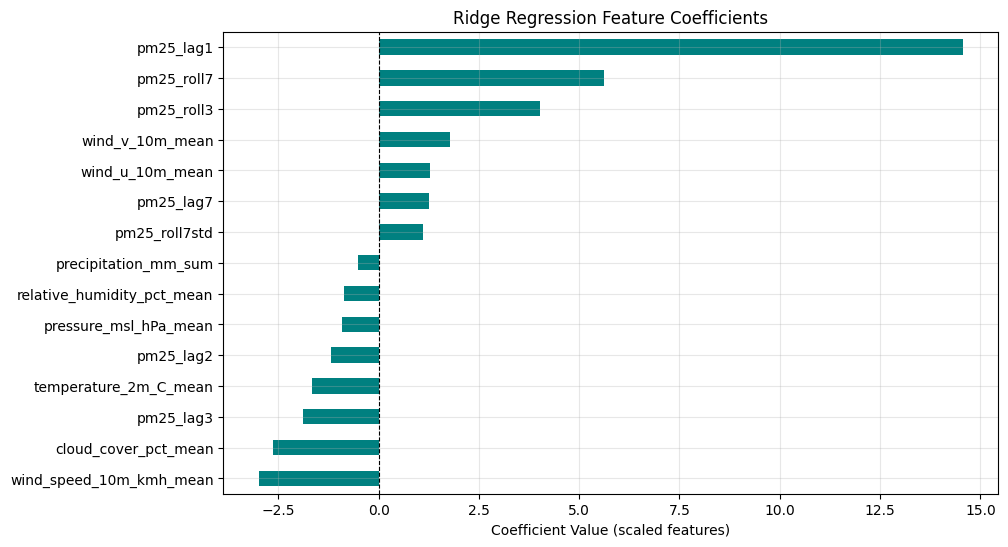

In [4]:
coefs = pd.Series(ridge.coef_, index=FEATURE_COLS).sort_values()
plt.figure(figsize=(10, 6))
coefs.plot(kind="barh", color="teal")
plt.title("Ridge Regression Feature Coefficients")
plt.xlabel("Coefficient Value (scaled features)")
plt.axvline(0, color="black", lw=0.8, ls="--")
plt.grid(True, alpha=0.3)
plt.show()
